# Imports

In [1]:
import keras
import datasets
from datasets import load_dataset
import numpy as np
import transformers
import sklearn.metrics
import tensorflow as tf
import tqdm.notebook as tqdm
import sklearn.model_selection
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except:
        pass

In [1]:
import tensorflow as tf
import os

# Проверяем доступные GPU
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    gpu_details = tf.config.experimental.get_device_details(gpus[0])
    gpu_name = gpu_details.get("device_name", "Unknown GPU")

    # Разрешаем динамическое выделение памяти
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except:
        pass

    print(f"✅ TensorFlow видит GPU: {gpu_name}")
else:
    print("⚠️ GPU не обнаружена — будет использоваться CPU.")

# Дополнительно можно проверить версию TensorFlow
print(f"TensorFlow version: {tf.__version__}")


⚠️ GPU не обнаружена — будет использоваться CPU.
TensorFlow version: 2.17.1


# Dataset

Load the dataset (we will be using [go_emotions](https://huggingface.co/datasets/google-research-datasets/go_emotions)). Pretokenize data or make a loader that tokenizes the sentenses as you iterate through the dataset. Implement two datasets: variable and fixed sentence length (in tokens). Don't forget to split the dataset into train and test subsets

In [3]:
dataset = datasets.load_dataset('google-research-datasets/go_emotions', name='raw', split='train')

In [4]:
print(dataset)

Dataset({
    features: ['text', 'id', 'author', 'subreddit', 'link_id', 'parent_id', 'created_utc', 'rater_id', 'example_very_unclear', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'],
    num_rows: 211225
})


In [4]:
emotions = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity',
    'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

# Множество для отслеживания уникальных текстов
seen_texts = set()
X_texts = []
y_labels = []

for row in dataset:
    text = row['text']
    if text not in seen_texts:
        seen_texts.add(text)
        X_texts.append(text)
        y_labels.append([row[e] for e in emotions])

y_labels = np.array(y_labels)

print(f"Осталось {len(X_texts)} уникальных примеров")
# X_texts = dataset['text']
# y_labels = np.array([ [row[e] for e in emotions] for row in dataset ])

Осталось 57732 уникальных примеров


In [5]:
emotions = [
    'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity',
    'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
    'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

X_texts = dataset['text']
y_labels = np.array([ [row[e] for e in emotions] for row in dataset ])

In [5]:
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    X_texts, y_labels, test_size=0.2, random_state=42
)

In [7]:
# print("Total examples:", len(dataset))

Total examples: 211225


In [15]:
# emotions = [
#     'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity',
#     'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear',
#     'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief',
#     'remorse', 'sadness', 'surprise', 'neutral'
# ]

In [16]:
# n_labels = len(emotions)
# print("Num labels:", n_labels)

Num labels: 28


In [6]:
tokenizer = transformers.AutoTokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token

In [7]:
# Set parameters
max_length = 64  # Based on dataset statistics (median ~17 tokens)
batch_size = 32

In [11]:
# # fixed: pad/truncate to max_length, return numpy arrays
# # паддинг для всего датасета
# def tokenize_fixed(texts):
#     enc = tokenizer(texts, truncation=True, padding='max_length', max_length=max_length, return_tensors='np', return_attention_mask=True)
#     return enc['input_ids'], enc['attention_mask']

# X_train_fixed_ids, X_train_fixed_mask = tokenize_fixed(X_train_texts)
# X_test_fixed_ids,  X_test_fixed_mask  = tokenize_fixed(X_test_texts)

# train_ds_fixed = tf.data.Dataset.from_tensor_slices(
#     ({"input_ids": X_train_fixed_ids, "attention_mask": X_train_fixed_mask}, y_train)
# ).shuffle(2048).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# test_ds_fixed = tf.data.Dataset.from_tensor_slices(
#     ({"input_ids": X_test_fixed_ids, "attention_mask": X_test_fixed_mask}, y_test)
# ).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [8]:
def tokenize_fixed(texts):
    enc = tokenizer(texts, truncation=True, padding='max_length', max_length=max_length, return_tensors='np', return_attention_mask=True)
    return enc['input_ids'], enc['attention_mask']

X_train_fixed_ids, X_train_fixed_mask = tokenize_fixed(X_train_texts)
X_test_fixed_ids,  X_test_fixed_mask  = tokenize_fixed(X_test_texts)

# === Исправляем ключи под Input_IDs ===
train_ds_fixed = tf.data.Dataset.from_tensor_slices(
    ({"Input_IDs": X_train_fixed_ids}, y_train)
).shuffle(2048).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds_fixed = tf.data.Dataset.from_tensor_slices(
    ({"Input_IDs": X_test_fixed_ids}, y_test)
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [9]:
n_labels = len(emotions)

In [13]:
# # variable-length: tokenize without padding, then use padded_batch (attention_mask included)
# # паддинг для батча
# def tokenize_variable(texts):
#     enc = tokenizer(texts, truncation=False, padding=False, return_tensors='np', return_attention_mask=True)
#     return enc['input_ids'], enc['attention_mask']

# X_train_var_ids, X_train_var_mask = tokenize_variable(X_train_texts)
# X_test_var_ids,  X_test_var_mask  = tokenize_variable(X_test_texts)

# # build generator-based dataset then padded_batch
# def make_var_ds(ids_list, mask_list, labels, batch_size):
#     def gen():
#         for ids, mask, lbl in zip(ids_list, mask_list, labels):
#             yield {"input_ids": ids.astype(np.int32), "attention_mask": mask.astype(np.int32)}, lbl.astype(np.float32)
#     # infer element_signature
#     element_spec = (
#         {"input_ids": tf.TensorSpec(shape=(None,), dtype=tf.int32),
#          "attention_mask": tf.TensorSpec(shape=(None,), dtype=tf.int32)},
#         tf.TensorSpec(shape=(n_labels,), dtype=tf.float32)
#     )
#     ds = tf.data.Dataset.from_generator(gen, output_signature=element_spec)
#     ds = ds.shuffle(2048).padded_batch(
#         batch_size,
#         padded_shapes=({"input_ids": [None], "attention_mask": [None]}, [n_labels]),
#         padding_values=({"input_ids": tokenizer.pad_token_id, "attention_mask": 0}, 0.0)
#     ).prefetch(tf.data.AUTOTUNE)
#     return ds

# train_ds_var = make_var_ds(X_train_var_ids, X_train_var_mask, y_train, batch_size)
# test_ds_var  = make_var_ds(X_test_var_ids, X_test_var_mask, y_test, batch_size)

Token indices sequence length is longer than the specified maximum sequence length for this model (1435 > 1024). Running this sequence through the model will result in indexing errors


In [10]:
def tokenize_variable(texts):
    enc = tokenizer(texts, truncation=False, padding=False, return_tensors='np', return_attention_mask=True)
    return enc['input_ids'], enc['attention_mask']

X_train_var_ids, X_train_var_mask = tokenize_variable(X_train_texts)
X_test_var_ids,  X_test_var_mask  = tokenize_variable(X_test_texts)

def make_var_ds(ids_list, labels, batch_size):
    def gen():
        for ids, lbl in zip(ids_list, labels):
            yield {"Input_IDs": ids.astype(np.int32)}, lbl.astype(np.float32)

    element_spec = ({"Input_IDs": tf.TensorSpec(shape=(None,), dtype=tf.int32)}, tf.TensorSpec(shape=(n_labels,), dtype=tf.float32))

    ds = tf.data.Dataset.from_generator(gen, output_signature=element_spec)
    ds = ds.shuffle(2048).padded_batch(
        batch_size,
        padded_shapes=({"Input_IDs": [None]}, [n_labels]),
        padding_values=({"Input_IDs": tokenizer.pad_token_id}, 0.0)
    ).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_var = make_var_ds(X_train_var_ids, y_train, batch_size)
test_ds_var  = make_var_ds(X_test_var_ids, y_test, batch_size)


Token indices sequence length is longer than the specified maximum sequence length for this model (1435 > 1024). Running this sequence through the model will result in indexing errors


# Model

Implement your model. The model should have the RNN architecture (with LSTM or GRU cells), support stacking and bidirectional feature extraction.

In [ ]:
# def get_model(
#     units: int,
#     n_tokens: int,
#     n_labels: int,
#     n_stacks: int = 1,
#     bidirectional: bool = False,
#     name: str | None = None,
#     cell_type: type[keras.layers.Layer] = keras.layers.LSTMCell
# ) -> keras.Model:
#     '''Creates a model with RNN architecture for sequence multilabel classification.

#     Arguments:
#         units: dimensionality of RNN cells
#         n_tokens: number of tokens in the tokenizer dictionary
#         n_labels: number of labels to be predicted
#         n_stacks: number of RNN cells in the stack (1 -- no stacking)
#         bidirectional: whether or not the model is bidirectional
#         name: the model name
#         cell_type: type of a cell to use, either keras.layers.LSTMCell or keras.layers.GRUCell

#     Returns:
#         The model'''

In [38]:
# def get_model(
#     units: int,
#     n_tokens: int,
#     n_labels: int,
#     n_stacks: int = 1,
#     bidirectional: bool = False,
#     name: str | None = None,
#     cell_type: type[keras.layers.Layer] = keras.layers.LSTMCell
# ) -> keras.Model:
#     inputs = keras.Input(shape=(None,), dtype="int32", name="input_ids")

#     x = keras.layers.Embedding(
#         input_dim=n_tokens,
#         output_dim=128,
#         mask_zero=True
#     )(inputs)

#     # RNN стек
#     for i in range(n_stacks):
#         if bidirectional:
#             x = keras.layers.Bidirectional(
#                 keras.layers.RNN(cell_type(units), return_sequences=True if i < n_stacks - 1 else False)
#             )(x)
#         else:
#             x = keras.layers.RNN(
#                 cell_type(units),
#                 return_sequences=True if i < n_stacks - 1 else False
#             )(x)

#     outputs = keras.layers.Dense(n_labels, activation="sigmoid")(x)
#     model = keras.Model(inputs, outputs, name=name)
#     return model

In [11]:
def get_name(prefix: str | None = None, suffix: str | None = None, separator: str = '_') -> str | None:
    return prefix and prefix + separator + suffix or suffix or None

In [12]:
class BoolMask(keras.layers.Layer):
    def call(self, inputs):
        return tf.cast(inputs > 0, tf.bool)

In [14]:
# def get_model(
#     units: int,
#     n_tokens: int,
#     n_labels: int,
#     n_stacks: int = 1,
#     bidirectional: bool = False,
#     name: str | None = None,
#     cell_type=keras.layers.LSTMCell,
#     embedding_dim: int = 128
# ) -> keras.Model:

#     inp_ids = keras.Input(shape=(None,), dtype='int32', name='input_ids')
#     inp_mask = keras.Input(shape=(None,), dtype='int32', name='attention_mask')

#     emb = keras.layers.Embedding(input_dim=n_tokens, output_dim=embedding_dim, mask_zero=False, name='embed')(inp_ids)

#     mask_bool = BoolMask(name='bool_mask')(inp_mask)

#     x = emb
#     for i in range(n_stacks):
#         return_seq = (i < n_stacks - 1)
#         rnn_layer = keras.layers.RNN(cell_type(units), return_sequences=return_seq)
#         if bidirectional:
#             rnn_layer = keras.layers.Bidirectional(rnn_layer)
#         x = rnn_layer(x, mask=mask_bool)

#     out = keras.layers.Dense(n_labels, activation='sigmoid')(x)

#     model = keras.Model(inputs=[inp_ids, inp_mask], outputs=out, name=name)
#     return model

In [16]:
# # без цикла
# # v1
# import tensorflow as tf
# from tensorflow import keras

# class BoolMask(keras.layers.Layer):
#     def call(self, inputs):
#         return tf.cast(inputs > 0, tf.bool)


# def get_model(
#     units: int,
#     n_tokens: int,
#     n_labels: int,
#     n_stacks: int = 1,
#     bidirectional: bool = False,
#     name: str | None = None,
#     cell_type=keras.layers.LSTMCell,
#     embedding_dim: int = 128
# ) -> keras.Model:

#     # === Входы ===
#     inp_ids = keras.Input(shape=(None,), dtype='int32', name='input_ids')
#     inp_mask = keras.Input(shape=(None,), dtype='int32', name='attention_mask')

#     # === Эмбеддинг ===
#     emb = keras.layers.Embedding(
#         input_dim=n_tokens,
#         output_dim=embedding_dim,
#         mask_zero=False,  # потому что мы используем свой attention_mask
#         name='embed'
#     )(inp_ids)

#     # === attention_mask → bool ===
#     mask_bool = BoolMask(name='bool_mask')(inp_mask)

#     # === Стекирование без цикла ===
#     cells = [cell_type(units) for _ in range(n_stacks)]
#     stacked_cells = keras.layers.StackedRNNCells(cells)
#     rnn_layer = keras.layers.RNN(
#         stacked_cells,
#         return_sequences=True,   # нужно для усреднения по маске
#         name='StackedRNN'
#     )

#     if bidirectional:
#         rnn_layer = keras.layers.Bidirectional(rnn_layer, name='BiStackedRNN')

#     seq_out = rnn_layer(emb)

#     # === Превращаем mask в float через Lambda ===
#     mask_float = keras.layers.Lambda(lambda x: tf.cast(x, tf.float32)[..., tf.newaxis], name="mask_float")(mask_bool)

#     # === Применяем маску к выходу ===
#     seq_out_masked = keras.layers.Multiply(name="masked_output")([seq_out, mask_float])

#     # === Усредняем по длине (с помощью Lambda) ===
#     seq_mean = keras.layers.Lambda(
#         lambda x: tf.reduce_sum(x[0], axis=1) / (tf.reduce_sum(x[1], axis=1) + 1e-9),
#         name="masked_mean"
#     )([seq_out_masked, mask_float])

#     # === Выход ===
#     out = keras.layers.Dense(n_labels, activation='sigmoid', name='output')(seq_mean)

#     model = keras.Model(inputs=[inp_ids, inp_mask], outputs=out, name=name)
#     return model

In [17]:
# # v2
# import tensorflow as tf
# from tensorflow import keras

# class BoolMask(keras.layers.Layer):
#     def call(self, inputs):
#         return tf.cast(inputs > 0, tf.bool)

# import tensorflow as tf
# from tensorflow import keras

# class BoolMask(keras.layers.Layer):
#     def call(self, inputs):
#         return tf.cast(inputs > 0, tf.bool)

# def get_model(
#     units: int,
#     n_tokens: int,
#     n_labels: int,
#     n_stacks: int = 1,
#     bidirectional: bool = False,
#     name: str | None = None,
#     cell_type=keras.layers.LSTMCell,
#     embedding_dim: int = 128
# ) -> keras.Model:
    
#     inp_ids = keras.Input(shape=(None,), dtype='int32', name='input_ids')
#     inp_mask = keras.Input(shape=(None,), dtype='int32', name='attention_mask')

#     # Embedding слой
#     emb = keras.layers.Embedding(
#         input_dim=n_tokens,
#         output_dim=embedding_dim,
#         mask_zero=False,
#         name='embedding'
#     )(inp_ids)

#     # Маска (True для непаддингов)
#     mask_bool = BoolMask(name='bool_mask')(inp_mask)

#     # Собираем стек RNN
#     cells = [cell_type(units) for _ in range(n_stacks)]
#     rnn = keras.layers.RNN(
#         keras.layers.StackedRNNCells(cells),
#         return_sequences=False,   # <--- теперь берём последний hidden state
#         name="StackedRNN"
#     )

#     # Bidirectional (если нужно)
#     if bidirectional:
#         rnn = keras.layers.Bidirectional(rnn, name="BidirectionalStackedRNN")

#     # Пропускаем через RNN
#     x = rnn(emb, mask=mask_bool)

#     # Выходной слой
#     out = keras.layers.Dense(n_labels, activation='sigmoid', name='output')(x)

#     # Финальная модель
#     model = keras.Model(inputs=[inp_ids, inp_mask], outputs=out, name=name)
#     return model

In [11]:
def get_name(prefix: str | None = None, suffix: str | None = None, separator: str = '_') -> str | None:
    return prefix and prefix + separator + suffix or suffix or None


def get_model(
    units: int,
    n_tokens: int,
    n_labels: int,
    n_stacks: int,
    embedding_dim: int,
    cell_type: type[keras.layers.Layer],
    bidirectional: bool = False,
    name: str | None = None,
    max_len: int = None,
    mask_zero: int = False

) -> keras.Model:

    '''Creates a model with RNN architecture for sequence multilabel classification.

    Arguments:
        units: dimensionality of RNN cells
        n_tokens: number of tokens in the tokenizer dictionary
        n_labels: number of labels to be predicted
        n_stacks: number of RNN cells in the stack (1 -- no stacking)
        bidirectional: whether or not the model is bidirectional
        name: the model name
        cell_type: type of a cell to use, either keras.layers.LSTMCell or keras.layers.GRUCell

    Returns:
        The model'''


    inputs = keras.layers.Input(shape=(max_len,), dtype="int32", name=get_name("Input", "IDs"))
    x = keras.layers.Embedding(input_dim=n_tokens, output_dim=embedding_dim, mask_zero=mask_zero, name=get_name("Embedding", "Layer"))(inputs)

    cells = [cell_type(units) for _ in range(n_stacks)]
    rnn_layer = keras.layers.RNN(cells, return_sequences=False, name="StackedRNN")
    
    if bidirectional:
      rnn_layer = keras.layers.Bidirectional(rnn_layer, name="BidirectionalStackedRNN")


    x = rnn_layer(x)

    outputs = keras.layers.Dense(n_labels, activation="sigmoid", name=get_name("Output", "Layer"))(x) # Подходит для multi-label классификации, когда один пример может принадлежать к нескольким классам.
    model = keras.models.Model(inputs=inputs, outputs=outputs, name=name)

    return model


# Training

Train several models on the two dataset variants. Use either of the cell types (LSTM or GRU)
* Simple RNN (no stacking, one direction)
* Stacked RNN (stacking, one direction)
* Bidirectional RNN (no stacking, bidirectional)
* Stacked Bidirectional RNN (stacking, bidirectional)

In [ ]:
# models = [
#     get_model(
#         units=...,
#         n_tokens=len(tokenizer.get_vocab()),
#         n_labels=len(emotions),
#         name=...,
#         bidirectional=...,
#         n_stacks=...,
#         cell_type=...
#     )
#     for ... in ...
# ]

Фиксированные

In [40]:
# models = [
#     get_model(128, len(tokenizer.get_vocab()), len(emotions), n_stacks=1, bidirectional=False, name="simple_lstm", cell_type=keras.layers.LSTMCell),
#     get_model(128, len(tokenizer.get_vocab()), len(emotions), n_stacks=2, bidirectional=False, name="stacked_lstm", cell_type=keras.layers.LSTMCell),
#     get_model(128, len(tokenizer.get_vocab()), len(emotions), n_stacks=1, bidirectional=True, name="bidir_lstm", cell_type=keras.layers.LSTMCell),
#     get_model(128, len(tokenizer.get_vocab()), len(emotions), n_stacks=2, bidirectional=True, name="stacked_bidir_lstm", cell_type=keras.layers.LSTMCell),
# ]


In [12]:
rnn_configs = [
    # (units, n_stacks, bidirectional, cell_type, name)
    (128, 1, False, keras.layers.LSTMCell, "simple_lstm"),
    (128, 2, False, keras.layers.LSTMCell, "stacked_lstm"),
    (128, 1, True,  keras.layers.LSTMCell, "bidir_lstm"),
    (128, 2, True,  keras.layers.LSTMCell, "stacked_bidir_lstm"),
]

models = [
    get_model(
        units=units,
        n_tokens=len(tokenizer.get_vocab()),
        n_labels=len(emotions),
        n_stacks=n_stacks,
        bidirectional=bidirectional,
        name=name,
        cell_type=cell_type,
        embedding_dim=128,
        max_len=64,
    )
    for (units, n_stacks, bidirectional, cell_type, name) in rnn_configs
]

In [21]:
print(models[0].name)

functional


In [18]:
# # =================== Настройка моделей ===================
# n_tokens = len(tokenizer)

# models = [
#     get_model(128, n_tokens, len(emotions), n_stacks=1, bidirectional=False, name="simple_lstm", cell_type=keras.layers.LSTMCell),
#     get_model(128, n_tokens, len(emotions), n_stacks=2, bidirectional=False, name="stacked_lstm", cell_type=keras.layers.LSTMCell),
#     get_model(128, n_tokens, len(emotions), n_stacks=1, bidirectional=True, name="bidir_lstm", cell_type=keras.layers.LSTMCell),
#     get_model(128, n_tokens, len(emotions), n_stacks=2, bidirectional=True, name="stacked_bidir_lstm", cell_type=keras.layers.LSTMCell),
# ]

Which loss should be used to multilabel classification? Which metrics?

In [ ]:
# for model in models:
#     model.compile(
#         loss=...,
#         optimizer=keras.optimizers.Adam(
#             ...
#         ),
#         metrics=[
#             ...
#         ]
#     )

In [13]:
for model in models:
    model.compile(
        loss='binary_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        metrics=[keras.metrics.AUC(curve='ROC', multi_label=True, name='auc_agg')]
    )
    model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Input_IDs (InputLayer)               │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Embedding_Layer (Embedding)          │ (None, 64, 128)             │       6,432,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ StackedRNN (RNN)                     │ (None, 128)                 │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 28)                  │           3,612 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,568,092 (25.06 MB)

 Trainable params: 6,568,092 (25.06 MB)

 Non-trainable params: 0 (0.00 B)

...

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Input_IDs (InputLayer)               │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Embedding_Layer (Embedding)          │ (None, 64, 128)             │       6,432,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ BidirectionalStackedRNN              │ (None, 256)                 │         526,336 │
│ (Bidirectional)                      │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Layer (Dense)                 │ (None, 28)                  │           7,196 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,966,428 (26.57 MB)

 Trainable params: 6,966,428 (26.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# for train_dataset, test_dataset in datasets:
#     for model in models:
#         model.fit(train_dataset, validation_data=test_dataset, epochs=...)

In [ ]:
# history = {}

# for model in models:
#     print(f"\nTraining {model.name}...")
#     hist = model.fit(
#         train_ds,
#         validation_data=test_ds,
#         epochs=3
#     )
#     history[model.name] = hist



Training simple_lstm...
Epoch 1/3


C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_ids
Received: inputs=['Tensor(shape=(None, 64))']
  warnings.warn(msg)


5281/5281 ━━━━━━━━━━━━━━━━━━━━ 275s 52ms/step - accuracy: 0.2603 - auc: 0.7224 - loss: 0.1588 - val_accuracy: 0.2648 - val_auc: 0.7238 - val_loss: 0.1574
Epoch 2/3
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 269s 51ms/step - accuracy: 0.2611 - auc: 0.7237 - loss: 0.1580 - val_accuracy: 0.2648 - val_auc: 0.7238 - val_loss: 0.1574
Epoch 3/3
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 274s 52ms/step - accuracy: 0.2611 - auc: 0.7237 - loss: 0.1580 - val_accuracy: 0.2648 - val_auc: 0.7238 - val_loss: 0.1574

Training stacked_lstm...
Epoch 1/3
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 433s 81ms/step - accuracy: 0.2603 - auc: 0.7223 - loss: 0.1588 - val_accuracy: 0.2648 - val_auc: 0.7235 - val_loss: 0.1575
Epoch 2/3
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 430s 81ms/step - accuracy: 0.2611 - auc: 0.7235 - loss: 0.1580 - val_accuracy: 0.2648 - val_auc: 0.7235 - val_loss: 0.1575
Epoch 3/3
5281/5281 ━━━━━━━━━━━━━━━━━━━━ 433s 82ms/step - accuracy: 0.2611 - auc: 0.7235 - loss: 0.1580 - val_accuracy: 0.2648 - val_auc: 0.7235 - val_loss: 0.1575


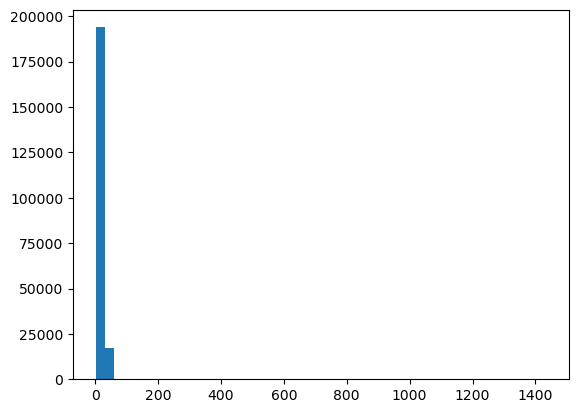

Median length: 17.0, 95th percentile: 31.0


In [18]:
# проверка токенов:

lengths = [len(tokenizer.encode(text)) for text in X_texts]
import matplotlib.pyplot as plt
plt.hist(lengths, bins=50)
plt.show()
print(f"Median length: {np.median(lengths)}, 95th percentile: {np.percentile(lengths, 95)}")


In [71]:
# import os
# from tensorflow.keras.callbacks import ModelCheckpoint

# datasets_list = [
#     ("fixed", train_ds_fixed, test_ds_fixed),
#     ("variable", train_ds_var, test_ds_var),
# ]

In [14]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint

datasets_list = [
    ("fixed", train_ds_fixed, test_ds_fixed),
    ("variable", train_ds_var, test_ds_var),
]

os.makedirs("saved_models", exist_ok=True)

history_all = {}

for dataset_name, train_data, test_data in datasets_list:
    print(f"\n===== Training on {dataset_name}-length dataset =====")
    for model in models:
        print(f"Model: {model.name}")
        
        checkpoint_path = f"saved_models/{dataset_name}_{model.name}_best.keras"
        
        checkpoint = ModelCheckpoint(
            filepath=checkpoint_path,
            monitor='val_auc_agg',
            mode='max',
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        )
        
        hist = model.fit(
            train_data,
            validation_data=test_data,
            epochs=10,
            callbacks=[checkpoint],
            verbose=1
        )
        
        history_all[(dataset_name, model.name)] = hist
        print(f"🦆 Best model for {model.name} saved to {checkpoint_path}")


===== Training on fixed-length dataset =====
Model: functional
Epoch 1/10


C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: Input_IDs
Received: inputs=['Tensor(shape=(None, 64))']
  warnings.warn(msg)


1444/1444 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - auc_agg: 0.4955 - loss: 0.1759
Epoch 1: val_auc_agg improved from None to 0.49998, saving model to saved_models/fixed_functional_best.keras
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 127s 83ms/step - auc_agg: 0.5005 - loss: 0.1609 - val_auc_agg: 0.5000 - val_loss: 0.1590
Epoch 2/10
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - auc_agg: 0.4934 - loss: 0.1581
Epoch 2: val_auc_agg improved from 0.49998 to 0.50005, saving model to saved_models/fixed_functional_best.keras
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 106s 73ms/step - auc_agg: 0.4996 - loss: 0.1579 - val_auc_agg: 0.5001 - val_loss: 0.1592
Epoch 3/10
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - auc_agg: 0.4975 - loss: 0.1580
Epoch 3: val_auc_agg did not improve from 0.50005
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 105s 72ms/step - auc_agg: 0.5032 - loss: 0.1579 - val_auc_agg: 0.5000 - val_loss: 0.1591
Epoch 4/10
1443/1444 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - auc_agg: 0.4960 - loss: 0.1579
Epoch 4: val_auc_agg did not

C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: Input_IDs
Received: inputs=['Tensor(shape=(None, None))']
  warnings.warn(msg)


   1443/Unknown 83s 55ms/step - auc_agg: 0.4978 - loss: 0.1576

C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_auc_agg improved from None to 0.54391, saving model to saved_models/variable_functional_best.keras
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 94s 62ms/step - auc_agg: 0.5120 - loss: 0.1573 - val_auc_agg: 0.5439 - val_loss: 0.1575
Epoch 2/10
1443/1444 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - auc_agg: 0.5342 - loss: 0.1552
Epoch 2: val_auc_agg improved from 0.54391 to 0.57811, saving model to saved_models/variable_functional_best.keras
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 87s 59ms/step - auc_agg: 0.5510 - loss: 0.1533 - val_auc_agg: 0.5781 - val_loss: 0.1551
Epoch 3/10
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - auc_agg: 0.6021 - loss: 0.1484
Epoch 3: val_auc_agg improved from 0.57811 to 0.67219, saving model to saved_models/variable_functional_best.keras
1444/1444 ━━━━━━━━━━━━━━━━━━━━ 90s 61ms/step - auc_agg: 0.6323 - loss: 0.1453 - val_auc_agg: 0.6722 - val_loss: 0.1420
Epoch 4/10
1443/1444 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - auc_agg: 0.7089 - loss: 0.1346
Epoch 4: val_auc_agg improved from 0

In [15]:
for name, model in models_all.items():
    print(f"\n=== {name} ===")
    model.summary()

NameError: name 'models_all' is not defined

# Загрузка моделей

In [30]:
import tensorflow as tf
from tensorflow import keras

# Разрешаем unsafe десериализацию (иначе Keras не позволит загружать Lambda)
keras.config.enable_unsafe_deserialization()

# Патчим поведение Lambda: теперь она всегда возвращает форму входа
_original_lambda_init = keras.layers.Lambda.__init__
_original_compute_output_shape = keras.layers.Lambda.compute_output_shape

def _safe_lambda_init(self, function, **kwargs):
    # Если у слоя нет output_shape, задаём безопасный дефолт
    if "output_shape" not in kwargs:
        kwargs["output_shape"] = lambda s: s
    _original_lambda_init(self, function, **kwargs)

def _safe_compute_output_shape(self, input_shape):
    try:
        return _original_compute_output_shape(self, input_shape)
    except NotImplementedError:
        return input_shape

keras.layers.Lambda.__init__ = _safe_lambda_init
keras.layers.Lambda.compute_output_shape = _safe_compute_output_shape

print("Lambda-слой пропатчен: output_shape теперь безопасен.")


Lambda-слой пропатчен: output_shape теперь безопасен.


In [72]:
import os

models = []
model_dir = "saved_models"
model_names = [
    "simple_lstm",
    "stacked_lstm",
    "bidir_lstm",
    "stacked_bidir_lstm"
]
dataset_names = ["fixed", "variable"]

In [ ]:
# custom_objects = {"BoolMask": BoolMask}
# model = keras.models.load_model(path, custom_objects=custom_objects, safe_mode=False)

In [73]:
for dataset_name in dataset_names:
    for model_name in model_names:
        path = os.path.join(model_dir, f"{dataset_name}_{model_name}_best.keras")
        if os.path.exists(path):
            print(f"Загружается модель: {path}")
            try:
                custom_objects = {"BoolMask": BoolMask}
                model = keras.models.load_model(path, custom_objects=custom_objects, safe_mode=False)
                # model = keras.models.load_model(path, safe_mode=False)
                models.append(model)
                print(f"Успешно загружена: {model.name}")
            except Exception as e:
                print(f"Ошибка при загрузке {path}: {e}")
        else:
            print(f"Модель не найдена: {path}")

Загружается модель: saved_models\fixed_simple_lstm_best.keras
Успешно загружена: simple_lstm
Загружается модель: saved_models\fixed_stacked_lstm_best.keras
Успешно загружена: stacked_lstm
Загружается модель: saved_models\fixed_bidir_lstm_best.keras
Успешно загружена: bidir_lstm
Загружается модель: saved_models\fixed_stacked_bidir_lstm_best.keras
Успешно загружена: stacked_bidir_lstm
Загружается модель: saved_models\variable_simple_lstm_best.keras
Успешно загружена: simple_lstm
Загружается модель: saved_models\variable_stacked_lstm_best.keras
Успешно загружена: stacked_lstm
Загружается модель: saved_models\variable_bidir_lstm_best.keras
Успешно загружена: bidir_lstm
Загружается модель: saved_models\variable_stacked_bidir_lstm_best.keras
Успешно загружена: stacked_bidir_lstm


In [28]:
import tensorflow as tf
from tensorflow import keras
import keras.saving
import os

# Разрешаем небезопасную десериализацию (чтобы не падало на lambda)
keras.config.enable_unsafe_deserialization()

# Переопределяем Lambda слой с фиксированной output_shape
class FixedLambda(keras.layers.Lambda):
    def __init__(self, function, **kwargs):
        super().__init__(function, **kwargs)

    def compute_output_shape(self, input_shape):
        return input_shape  # фикс для bool_mask

custom_objects = {"FixedLambda": FixedLambda}

models = []
model_dir = "saved_models"
model_names = [
    "simple_lstm",
    "stacked_lstm",
    "bidir_lstm",
    "stacked_bidir_lstm"
]
dataset_names = ["fixed", "variable"]

In [74]:
model_names = ["simple_lstm", "stacked_lstm", "bidir_lstm", "stacked_bidir_lstm"]
dataset_types = ["fixed", "variable"]

In [94]:
models_all = {}

for dataset_type in dataset_types:
    for name in model_names:
        full_name = f"{dataset_type}_{name}"
        # количество слоёв и bidirectional
        n_stacks = 2 if "stacked" in name else 1
        bidir = "bidir" in name

        model = get_model(
            128, n_tokens, n_labels,
            n_stacks=n_stacks,
            bidirectional=bidir,
            name=full_name,
            cell_type=keras.layers.LSTMCell
        )

        # ------------------- Загружаем веса из старой модели -------------------
        path = f"saved_models/{full_name}_best.keras"
        if os.path.exists(path):
            try:
                old_model = keras.models.load_model(path, compile=False, safe_mode=True)
                model.set_weights(old_model.get_weights())
                print(f"Веса для модели {full_name} успешно загружены")
            except Exception as e:
                print(f"Ошибка при загрузке весов {path}: {e}")

        model.compile(
            loss='binary_crossentropy',
            optimizer=keras.optimizers.Adam(1e-3),
            metrics=[keras.metrics.AUC(curve='ROC', multi_label=True, name='auc_agg')]
        )

        models_all[full_name] = model

Веса для модели fixed_simple_lstm успешно загружены
Веса для модели fixed_stacked_lstm успешно загружены
Веса для модели fixed_bidir_lstm успешно загружены
Веса для модели fixed_stacked_bidir_lstm успешно загружены
Веса для модели variable_simple_lstm успешно загружены
Веса для модели variable_stacked_lstm успешно загружены
Веса для модели variable_bidir_lstm успешно загружены
Веса для модели variable_stacked_bidir_lstm успешно загружены


In [81]:
models_all = {}

for dataset_type in dataset_types:
    for name in model_names:
        full_name = f"{dataset_type}_{name}"
        # количество слоёв и bidirectional
        n_stacks = 2 if "stacked" in name else 1
        bidir = "bidir" in name

        model = get_model(
            128, n_tokens, n_labels,
            n_stacks=n_stacks,
            bidirectional=bidir,
            name=full_name,
            cell_type=keras.layers.LSTMCell
        )

        # ------------------- Загружаем веса из старой модели -------------------
        path = f"saved_models/{full_name}_best.keras"
        if os.path.exists(path):
            try:
                old_model = keras.models.load_model(
                    path,
                    compile=False,
                    safe_mode=True,
                    custom_objects={'BoolMask': BoolMask, 'tf': tf}
                )
                model.set_weights(old_model.get_weights())
                print(f"Веса для модели {full_name} успешно загружены")
            except Exception as e:
                print(f"Ошибка при загрузке весов {path}: {e}")

        model.compile(
            loss='binary_crossentropy',
            optimizer=keras.optimizers.Adam(1e-3),
            metrics=[keras.metrics.AUC(curve='ROC', multi_label=True, name='auc_agg')]
        )

        models_all[full_name] = model


Веса для модели fixed_simple_lstm успешно загружены
Веса для модели fixed_stacked_lstm успешно загружены
Веса для модели fixed_bidir_lstm успешно загружены
Веса для модели fixed_stacked_bidir_lstm успешно загружены
Веса для модели variable_simple_lstm успешно загружены
Веса для модели variable_stacked_lstm успешно загружены
Веса для модели variable_bidir_lstm успешно загружены
Веса для модели variable_stacked_bidir_lstm успешно загружены


# Evaluation

Evaluate the models you trained on the test datasets. Plot ROC curves for each label (use `sklearn.metrics.RocCurveDisplay`) for each model.

In [16]:
import tensorflow as tf
def eval_and_plot_roc(model, test_dataset, emotions_list, n_samples=None, figsize=(8,8)):
    # collect predictions and labels
    y_true = []
    y_scores = []
    for batch_x, batch_y in test_dataset:
        preds = model.predict(batch_x, verbose=0)
        y_scores.append(preds)
        y_true.append(batch_y.numpy())
    y_true = np.vstack(y_true)
    y_scores = np.vstack(y_scores)

    # compute per-label AUC where applicable
    aucs = []
    fig, ax = plt.subplots(figsize=figsize)
    for i, label in enumerate(emotions_list):
        # skip if y_true has no positive samples
        if np.unique(y_true[:, i]).sum() == 0:
            print(f"Label {label}: no positive samples in test; skipping ROC")
            continue
        RocCurveDisplay.from_predictions(y_true[:, i], y_scores[:, i], name=label, ax=ax, alpha=0.4)
        try:
            auc_val = roc_auc_score(y_true[:, i], y_scores[:, i])
        except ValueError:
            auc_val = np.nan
        aucs.append(auc_val)
    mean_auc = np.nanmean(aucs)
    ax.set_title(f"{model.name} mean AUC = {mean_auc:.4f}")
    ax.legend(fontsize='small', bbox_to_anchor=(1.05,1))
    plt.tight_layout()
    return mean_auc, y_true, y_scores

In [17]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rn

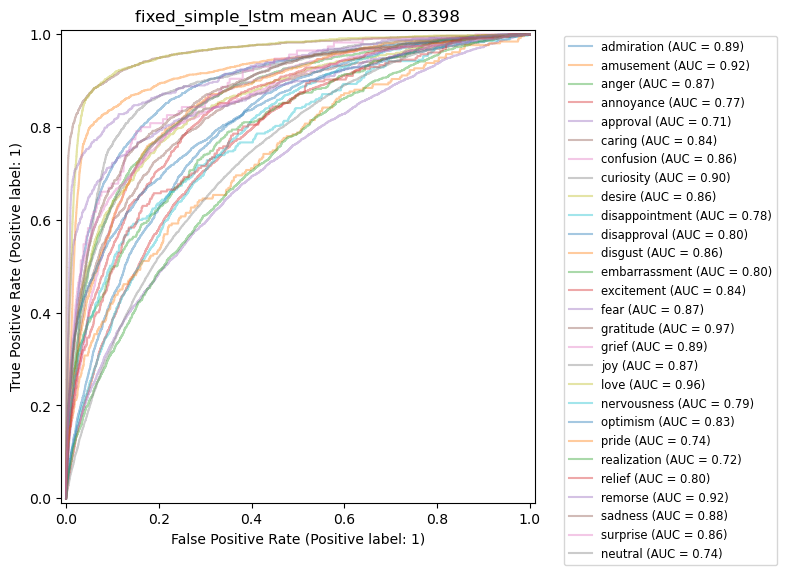

In [53]:
mean_auc, y_true, y_scores = eval_and_plot_roc(models_all["fixed_simple_lstm"], test_ds_fixed, emotions)

Модель: fixed_simple_lstm


C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rn

Модель: fixed_stacked_lstm


C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rn

Модель: fixed_bidir_lstm


...

C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rn

Модель: variable_bidir_lstm


C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rn

Модель: variable_stacked_bidir_lstm


C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rn

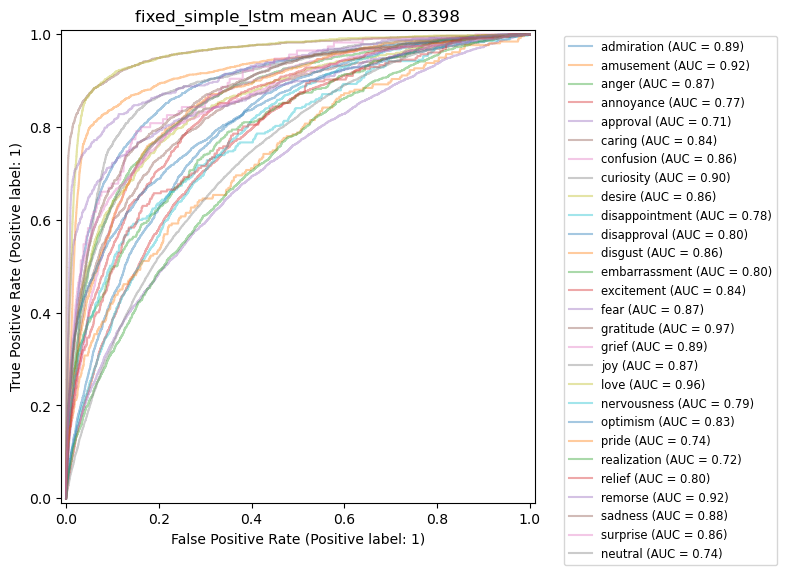

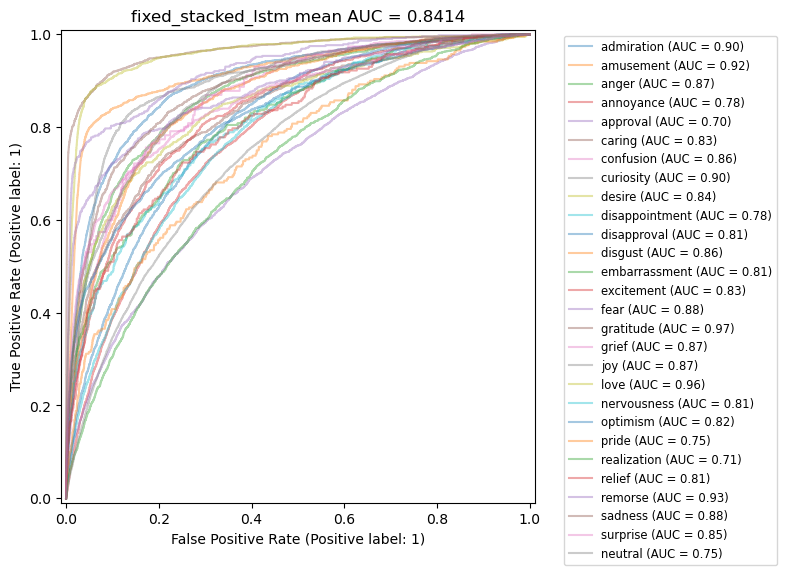

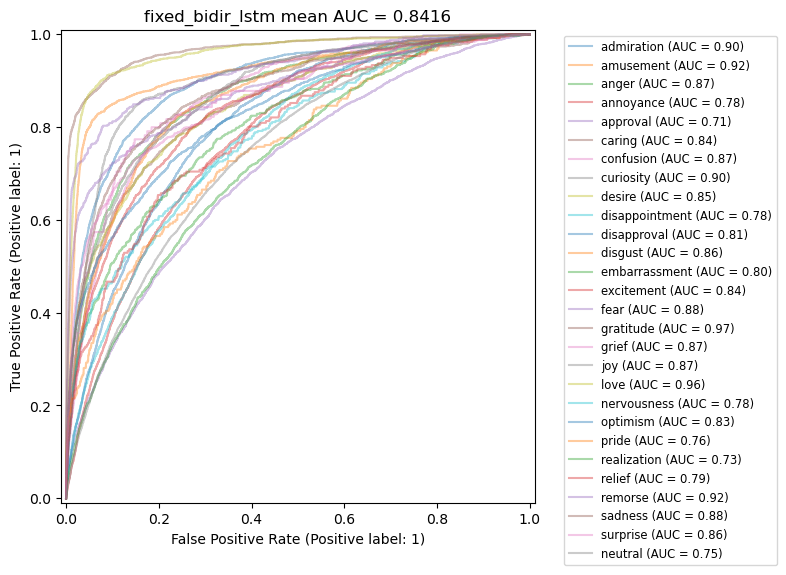

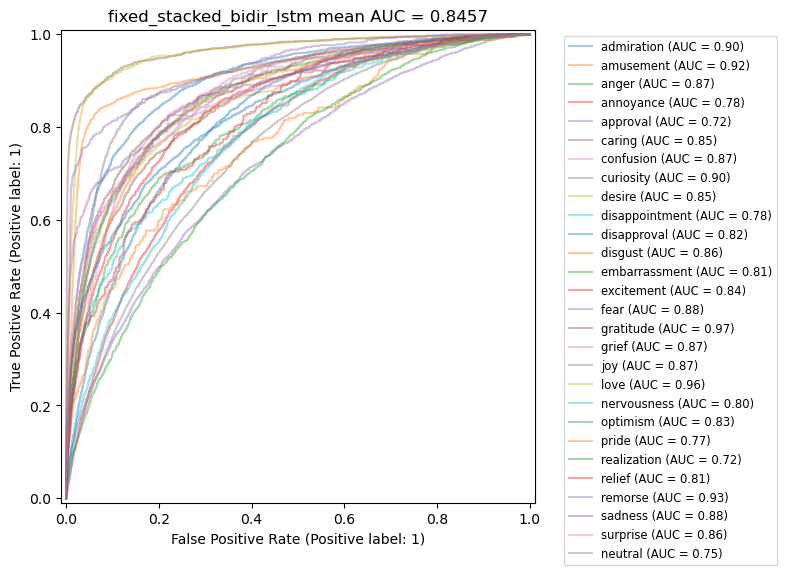

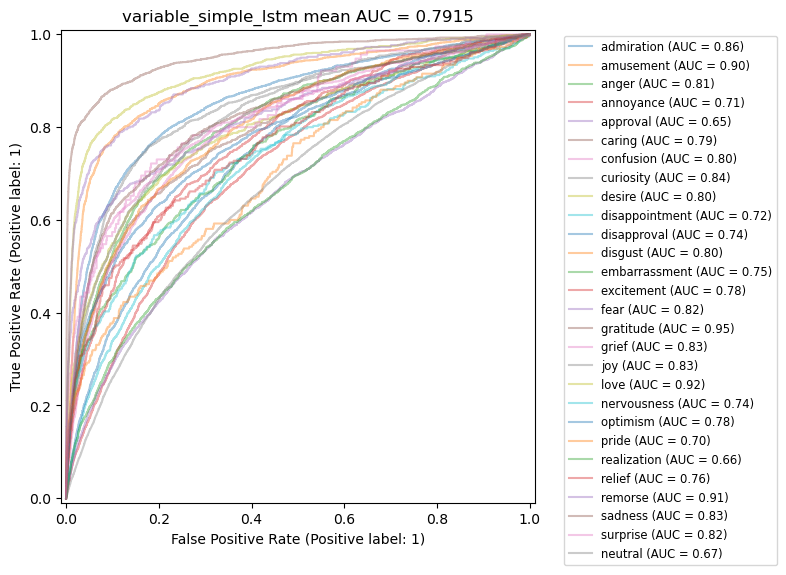

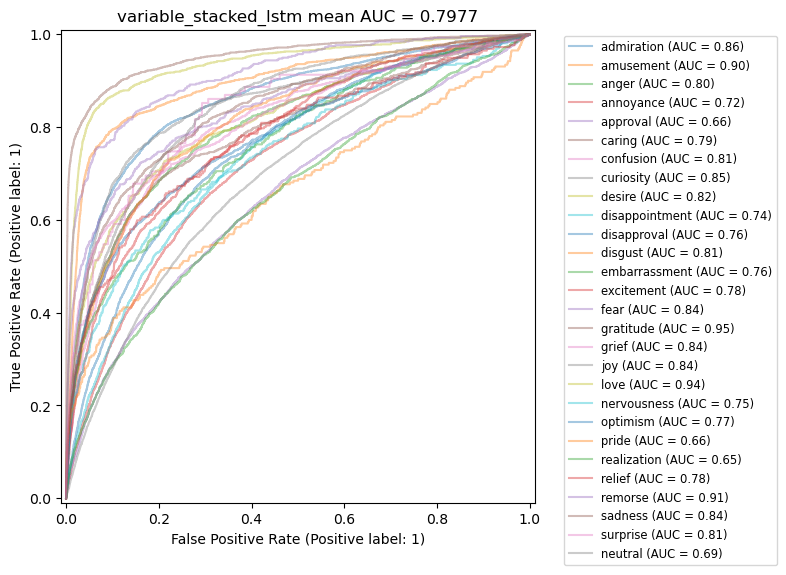

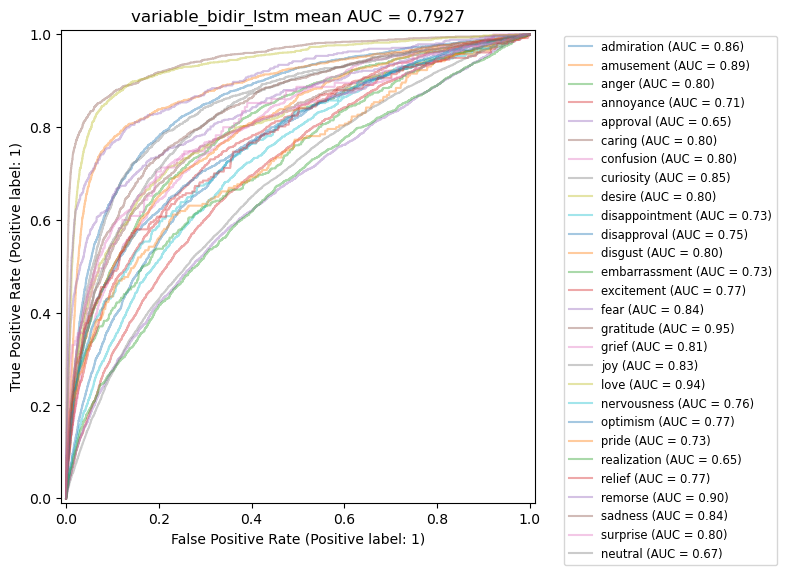

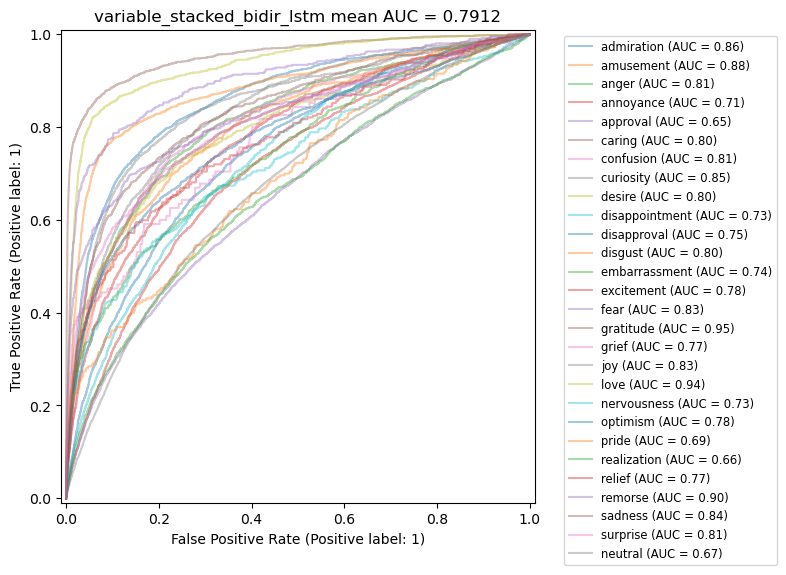

In [54]:
for key, model in models_all.items():
    print(f"Модель: {key}")
    mean_auc, y_true, y_scores = eval_and_plot_roc(model, test_ds_fixed, emotions)

# Сравнение моделей

In [76]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

results = {}

for name, model in models_all.items():
    y_true_list = []
    y_scores_list = []

    for batch_x, batch_y in test_ds_fixed:   # тестовый набор
        y_true_list.append(batch_y.numpy())
        y_scores_list.append(model.predict(batch_x, verbose=0))

    y_true = np.vstack(y_true_list)
    y_scores = np.vstack(y_scores_list)

    # AUC для каждого класса
    aucs = []
    for i in range(y_true.shape[1]):
        if np.unique(y_true[:, i]).sum() > 0:  # если есть положительные примеры
            aucs.append(roc_auc_score(y_true[:, i], y_scores[:, i]))
    
    results[name] = np.mean(aucs)  # усреднённый AUC по всем классам

df_auc = pd.DataFrame(list(results.items()), columns=['Model', 'Mean AUC']).sort_values('Mean AUC', ascending=False)
print(df_auc)


                         Model  Mean AUC
3     fixed_stacked_bidir_lstm  0.845676
2             fixed_bidir_lstm  0.841647
1           fixed_stacked_lstm  0.841390
0            fixed_simple_lstm  0.839813
5        variable_stacked_lstm  0.797747
6          variable_bidir_lstm  0.792700
4         variable_simple_lstm  0.791545
7  variable_stacked_bidir_lstm  0.791172


In [77]:
import pandas as pd

fixed_rows = []
variable_rows = []

for name, auc in results.items():
    if name.startswith("fixed"):
        fixed_rows.append((name, auc))
    elif name.startswith("variable"):
        variable_rows.append((name, auc))

# Сортируем по модели, чтобы пары совпадали
fixed_rows = sorted(fixed_rows, key=lambda x: x[0].replace("fixed_", ""))
variable_rows = sorted(variable_rows, key=lambda x: x[0].replace("variable_", ""))

# Собираем в один DataFrame
data = []
for f, v in zip(fixed_rows, variable_rows):
    data.append({
        "fixed": f[0],
        "Mean AUC (fixed)": f[1],
        "variable": v[0],
        "Mean AUC (variable)": v[1]
    })

df_compare = pd.DataFrame(data)
df_compare


,fixed,Mean AUC (fixed),variable,Mean AUC (variable)
0,fixed_bidir_lstm,0.841647,variable_bidir_lstm,0.792700
1,fixed_simple_lstm,0.839813,variable_simple_lstm,0.791545
2,fixed_stacked_bidir_lstm,0.845676,variable_stacked_bidir_lstm,0.791172
3,fixed_stacked_lstm,0.841390,variable_stacked_lstm,0.797747


In [50]:
# 1 модель
mean_auc, y_true, y_scores = eval_and_plot_roc(models[0], test_ds_fixed, emotions)

NameError: Exception encountered when calling Lambda.call().

[1mname 'tf' is not defined[0m

Arguments received by Lambda.call():
  • inputs=tf.Tensor(shape=(32, 64), dtype=int32)
  • mask=None
  • training=False

In [78]:
# ---------------------------
# 7) Helper: label_text and plot_emotion_scores
# ---------------------------
def label_text(text: str, model: keras.Model, threshold: float = 0.5, max_length: int = 64):
    enc = tokenizer(text, truncation=True, padding='max_length', max_length=max_length, return_tensors='np', return_attention_mask=True)
    inp = {"input_ids": enc['input_ids'], "attention_mask": enc['attention_mask']}
    preds = model.predict(inp)
    preds = preds.reshape(-1, n_labels)[0]
    return [emotions[i] for i, p in enumerate(preds) if p >= threshold], preds

In [79]:
def plot_emotion_scores(text: str, model: keras.Model, max_length: int = 64, ax=None):
    labels, preds = label_text(text, model, threshold=0.0, max_length=max_length)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12,4))
    ax.bar(emotions, preds)
    ax.set_xticklabels(emotions, rotation=90)
    ax.set_ylim(0,1)
    ax.set_title(text)
    plt.tight_layout()

# Эксперименты

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Predicted labels: ['excitement', 'joy']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


C:\Users\maxim\AppData\Local\Temp\ipykernel_12660\1285591675.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(emotions, rotation=90)


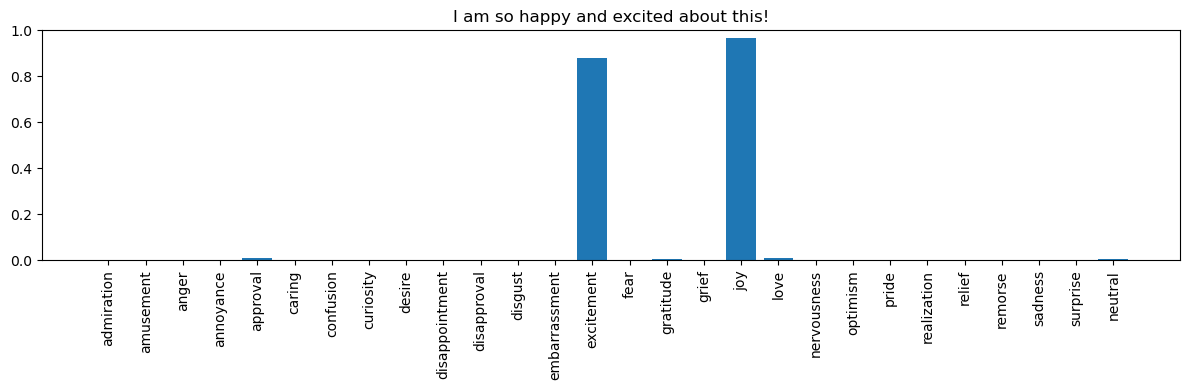

In [85]:
# Example quick check:
s = "I am so happy and excited about this!"
pred_labels, preds = label_text(s, models_all['variable_simple_lstm'], threshold=0.3)
print("Predicted labels:", pred_labels)
plot_emotion_scores(s, models_all['variable_simple_lstm'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted labels: ['fear', 'nervousness']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


C:\Users\maxim\AppData\Local\Temp\ipykernel_12660\1285591675.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(emotions, rotation=90)


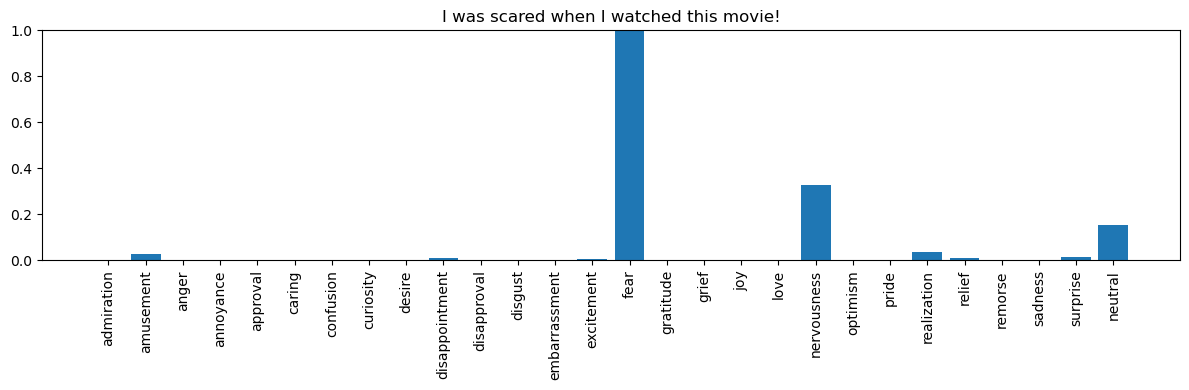

In [86]:
s = "I was scared when I watched this movie!"
pred_labels, preds = label_text(s, models_all['variable_simple_lstm'], threshold=0.3)
print("Predicted labels:", pred_labels)
plot_emotion_scores(s, models_all['variable_simple_lstm'])
plt.show()

In [ ]:
# def plot_roc_curve(
#     X: np.ndarray,
#     y: np.ndarray,
#     model: keras.Model,
#     ax: plt.Axes | None = None
# ) -> float:
#     '''Plots ROC curves for each of the labels (on a single axes) and outputs mean ROC AUC score.

#     Arguments:
#         X: model inputs
#         y: ground thruths
#         model: model to plot the curve for
#         ax: axes to plot on

#     Returns:
#         Mean ROC AUC score'''

In [ ]:
# from sklearn.metrics import roc_auc_score, RocCurveDisplay

# def plot_roc_curve(X, y, model, ax=None):
#     y_pred = model.predict(X)
#     auc = roc_auc_score(y, y_pred, average="macro")
#     if ax is not None:
#         RocCurveDisplay.from_predictions(
#             y.ravel(), y_pred.ravel(), ax=ax, name=model.name
#         )
#     return auc


In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

def plot_roc_curve(X, y, model, ax=None):
    y_pred = model.predict(X)
    auc = roc_auc_score(y, y_pred, average='macro')
    if ax is not None:
        RocCurveDisplay.from_predictions(y.ravel(), y_pred.ravel(), ax=ax, name=model.name)
    return auc

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
#  v 2
def plot_roc_curve(X, y, model, ax=None):
    y_pred = model.predict(X)
    aucs = []
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    for i, emotion in enumerate(emotions):
        RocCurveDisplay.from_predictions(
            y[:, i], y_pred[:, i], ax=ax, name=emotion, alpha=0.3
        )
        aucs.append(roc_auc_score(y[:, i], y_pred[:, i]))
    mean_auc = np.mean(aucs)
    ax.set_title(f"{model.name} | mean AUC = {mean_auc:.3f}")
    return mean_auc


Plot the mean ROC AUC scores. Which model has the highest score? On what kind of dataset?

Inspect the best model performance closer. Come up with some sentences (in English). Does the model output sensible results?

In [ ]:
# def label_text(text: str, model: keras.Model, threshold: float = 0.5, max_length: int | None = None) -> list[str]:
#     '''Computes the model output for `text` and outputs a list of emotions that have a probability of at least `threshold`

#     Arguments:
#         text: text to label
#         model: model to use
#         threshold: threshold to use
#         max_length: max length for tokenization
    
#     Return:
#         List of predicted emotion labels'''

In [ ]:
# def plot_emotion_scores(text: str, model: keras.Model, max_length: int | None = None, ax: plt.Axes | None = None):
#     '''Plots a bar plot of emotion probabilities for given `text` using `model`.

#     Arguments:
#         text: text to label
#         model: model to use        
#         max_length: max length for tokenization
#         ax: axes to plot on'''

For each of your texts get a list of emotion labels and plot emotion scores

In [ ]:
# def label_text(text, model, threshold=0.5, max_length=64):
#     enc = tokenizer(text, truncation=True, padding="max_length", max_length=max_length, return_tensors="tf")
#     preds = model(enc["input_ids"])
#     preds = tf.squeeze(preds).numpy()
#     return [emotions[i] for i, p in enumerate(preds) if p >= threshold]


# def plot_emotion_scores(text, model, max_length=64, ax=None):
#     enc = tokenizer(text, truncation=True, padding="max_length", max_length=max_length, return_tensors="tf")
#     preds = model(enc["input_ids"])
#     preds = tf.squeeze(preds).numpy()
#     if ax is None:
#         fig, ax = plt.subplots(figsize=(10, 4))
#     ax.bar(emotions, preds)
#     ax.set_xticklabels(emotions, rotation=90)
#     ax.set_title(text)


In [ ]:
def label_text(text, model, threshold=0.5, max_length=64):
    enc = tokenizer(text, truncation=True, padding='max_length', max_length=max_length, return_tensors='tf')
    preds = tf.squeeze(model(enc["input_ids"])).numpy()
    return [emotions[i] for i,p in enumerate(preds) if p >= threshold]

def plot_emotion_scores(text, model, max_length=64, ax=None):
    enc = tokenizer(text, truncation=True, padding='max_length', max_length=max_length, return_tensors='tf')
    preds = tf.squeeze(model(enc["input_ids"])).numpy()
    if ax is None:
        fig, ax = plt.subplots(figsize=(12,4))
    ax.bar(emotions, preds)
    ax.set_xticklabels(emotions, rotation=90)
    ax.set_title(text)

In [ ]:
# v2
def plot_emotion_scores(text, model, max_length=64, ax=None):
    enc = tokenizer(text, truncation=True, padding='max_length', max_length=max_length, return_tensors='tf')
    preds = tf.squeeze(model(enc["input_ids"])).numpy()
    if ax is None:
        fig, ax = plt.subplots(figsize=(12,4))
    ax.bar(emotions, preds)
    plt.xticks(rotation=90)
    ax.set_title(text)


# Bonus

Train and evaluate the same model as your best one, but use a different cell type

In [ ]:
gru_model = get_model(
    128, tokenizer.vocab_size, len(emotions),
    n_stacks=2, bidirectional=True, name="stacked_bidir_gru", cell_type=keras.layers.GRUCell
)
gru_model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(1e-3),
    metrics=[keras.metrics.AUC(name='auc', multi_label=True), 'accuracy']
)
gru_model.fit(train_ds_fixed, validation_data=test_ds_fixed, epochs=10)


In [87]:
import os

models_gru = []
model_dir_gru = "saved_models_gru"
model_names_gru = [
    "stacked_gru",
    "stacked_bidir_gru"
]
dataset_names = ["fixed", "variable"]

In [92]:
models_all_gru = {}

for dataset_type in dataset_types:
    for name in model_names_gru:
        full_name = f"{dataset_type}_{name}"
        # количество слоёв и bidirectional
        n_stacks = 2 if "stacked" in name else 1
        bidir = "bidir" in name

        model = get_model(128, n_tokens, n_labels, n_stacks=n_stacks, bidirectional=bidir, name=full_name, cell_type=keras.layers.GRUCell)


        # ------------------- Загружаем веса из старой модели -------------------
        path = f"saved_models_gru/{full_name}_best.keras"
        # print("a")
        if os.path.exists(path):
            try:
                old_model = keras.models.load_model(
                    path,
                    compile=False,
                    safe_mode=False,
                    custom_objects={'BoolMask': BoolMask, 'tf': tf} 
                )
                model.set_weights(old_model.get_weights())
                print(f"Веса для модели {full_name} успешно загружены")
            except Exception as e:
                print(f"Ошибка при загрузке весов {path}: {e}")

        # ------------------- Компиляция -------------------
        model.compile(
            loss='binary_crossentropy',
            optimizer=keras.optimizers.Adam(1e-3),
            metrics=[keras.metrics.AUC(curve='ROC', multi_label=True, name='auc_agg')]
        )

        models_all_gru[full_name] = model


Веса для модели fixed_stacked_gru успешно загружены
Веса для модели fixed_stacked_bidir_gru успешно загружены
Веса для модели variable_stacked_gru успешно загружены
Веса для модели variable_stacked_bidir_gru успешно загружены


In [93]:
for name, model in models_all_gru.items():
    print(f"\n=== {name} ===")
    model.summary()


=== fixed_stacked_gru ===


Model: "fixed_stacked_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_mask (InputLayer)   │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embed (Embedding)             │ (None, None, 128)         │       6,432,896 │ input_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bool_mask (BoolMask)          │ (None, None)              │               0 │ attention_mask[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rnn_82 (RNN)                  │ (None, None, 128)         │          99,072 │ embed[0][0],               │
│                               │                           │                 │ bool_mask[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rnn_83 (RNN)                  │ (None, 128)               │          99,072 │ rnn_82[0][0],              │
│                               │                           │                 │ bool_mask[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_52 (Dense)              │ (None, 28)                │           3,612 │ rnn_83[0][0]               │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 6,634,652 (25.31 MB)

 Trainable params: 6,634,652 (25.31 MB)

...

Model: "variable_stacked_bidir_gru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_mask (InputLayer)   │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embed (Embedding)             │ (None, None, 128)         │       6,432,896 │ input_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bool_mask (BoolMask)          │ (None, None)              │               0 │ attention_mask[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_43              │ (None, None, 256)         │         198,144 │ embed[0][0],               │
│ (Bidirectional)               │                           │                 │ bool_mask[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_44              │ (None, 256)               │         296,448 │ bidirectional_43[0][0],    │
│ (Bidirectional)               │                           │                 │ bool_mask[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_55 (Dense)              │ (None, 28)                │           7,196 │ bidirectional_44[0][0]     │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 6,934,684 (26.45 MB)

 Trainable params: 6,934,684 (26.45 MB)

 Non-trainable params: 0 (0.00 B)

Модель: fixed_stacked_gru


C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rn

Модель: fixed_stacked_bidir_gru


C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rn

Модель: variable_stacked_gru


C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rn

Модель: variable_stacked_bidir_gru


C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rnn\lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
C:\Users\maxim\anaconda3\envs\rn

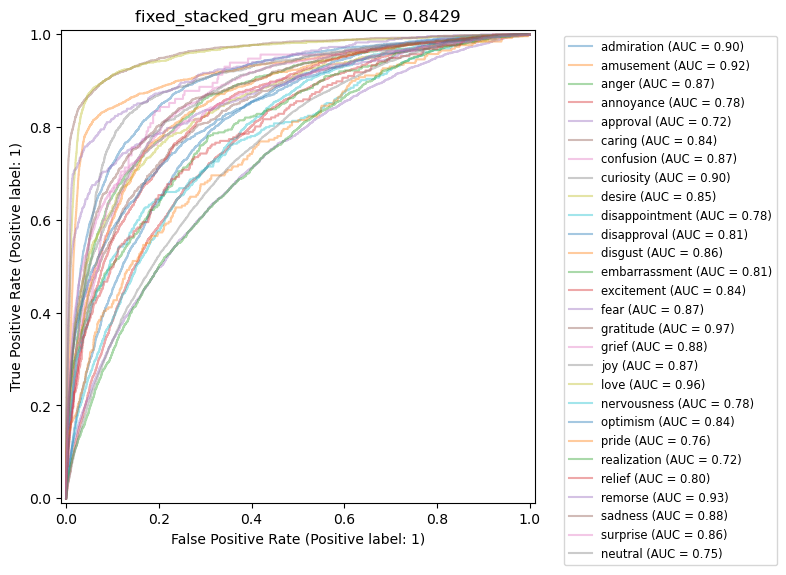

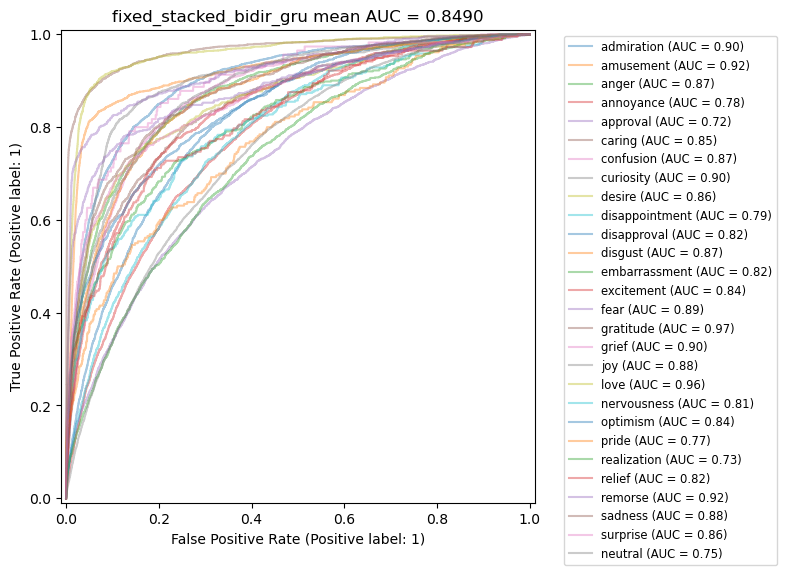

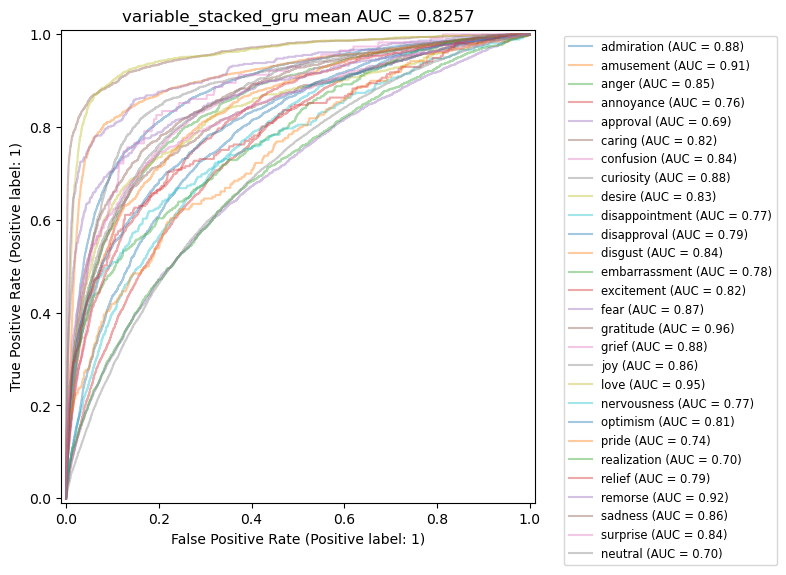

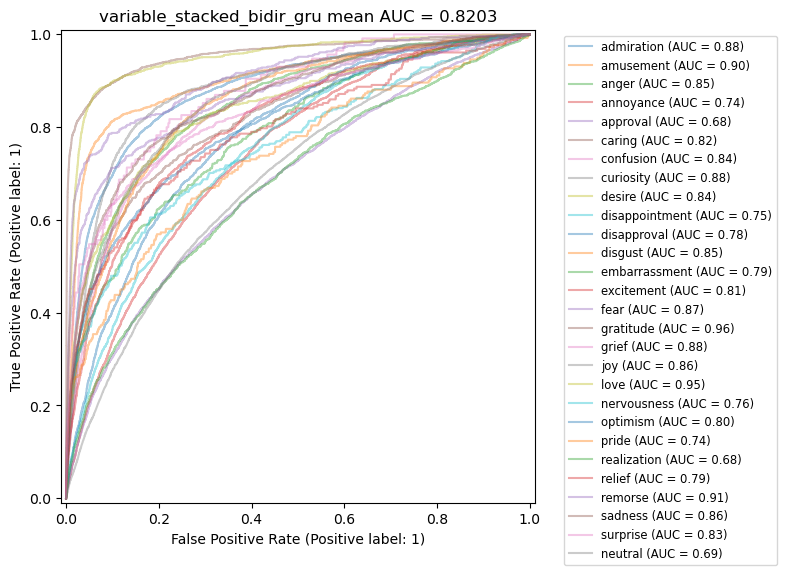

In [96]:
for key, model in models_all_gru.items():
    print(f"Модель: {key}")
    mean_auc, y_true, y_scores = eval_and_plot_roc(model, test_ds_fixed, emotions)

In [97]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

results_gru = {}

for name, model in models_all_gru.items():
    y_true_list = []
    y_scores_list = []

    for batch_x, batch_y in test_ds_fixed:   # тестовый набор
        y_true_list.append(batch_y.numpy())
        y_scores_list.append(model.predict(batch_x, verbose=0))

    y_true = np.vstack(y_true_list)
    y_scores = np.vstack(y_scores_list)

    # AUC для каждого класса
    aucs = []
    for i in range(y_true.shape[1]):
        if np.unique(y_true[:, i]).sum() > 0:  # если есть положительные примеры
            aucs.append(roc_auc_score(y_true[:, i], y_scores[:, i]))
    
    results_gru[name] = np.mean(aucs)  # усреднённый AUC по всем классам

df_auc_gru = pd.DataFrame(list(results_gru.items()), columns=['Model', 'Mean AUC']).sort_values('Mean AUC', ascending=False)
print(df_auc_gru)


                        Model  Mean AUC
1     fixed_stacked_bidir_gru  0.849000
0           fixed_stacked_gru  0.842851
2        variable_stacked_gru  0.825651
3  variable_stacked_bidir_gru  0.820311


In [98]:
import pandas as pd

fixed_rows_gru = []
variable_rows_gru = []

for name, auc in results_gru.items():
    if name.startswith("fixed"):
        fixed_rows_gru.append((name, auc))
    elif name.startswith("variable"):
        variable_rows_gru.append((name, auc))

fixed_rows_gru = sorted(fixed_rows_gru, key=lambda x: x[0].replace("fixed_", ""))
variable_rows_gru = sorted(variable_rows_gru, key=lambda x: x[0].replace("variable_", ""))

data_gru = []
for f, v in zip(fixed_rows_gru, variable_rows_gru):
    data_gru.append({
        "fixed": f[0],
        "Mean AUC (fixed)": f[1],
        "variable": v[0],
        "Mean AUC (variable)": v[1]
    })

df_compare_gru = pd.DataFrame(data_gru)
df_compare_gru

,fixed,Mean AUC (fixed),variable,Mean AUC (variable)
0,fixed_stacked_bidir_gru,0.849000,variable_stacked_bidir_gru,0.820311
1,fixed_stacked_gru,0.842851,variable_stacked_gru,0.825651


# Эксперименты

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted labels: ['excitement', 'joy']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


C:\Users\maxim\AppData\Local\Temp\ipykernel_12660\1285591675.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(emotions, rotation=90)


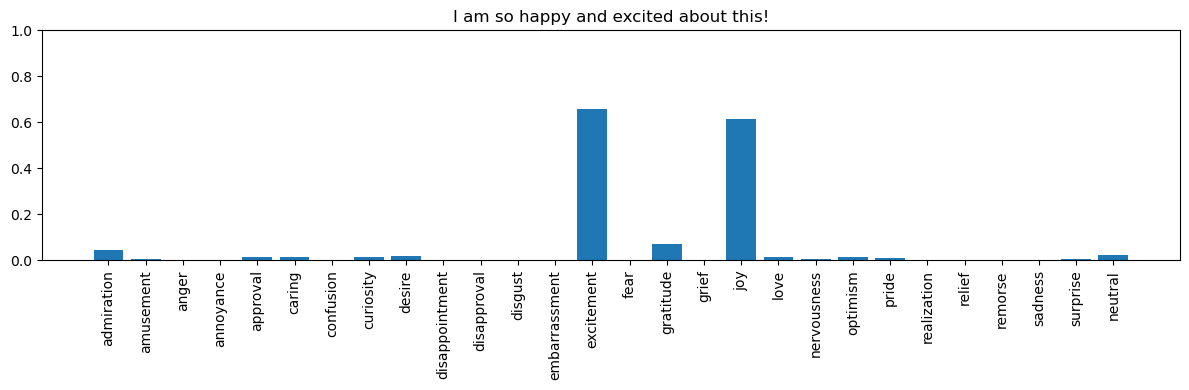

In [100]:
# Example quick check:

# fixed_stacked_bidir_gru_best

s = "I am so happy and excited about this!"
pred_labels, preds = label_text(s, models_all_gru['fixed_stacked_bidir_gru'], threshold=0.3)
print("Predicted labels:", pred_labels)
plot_emotion_scores(s, models_all_gru['fixed_stacked_bidir_gru'])
plt.show()